In [1]:
!pip install gradio xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
import pandas as pd

df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Remove customerID column

if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [9]:
# Convert TotalCharges to numeric

if "TotalCharges" in df.columns:

    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    df["TotalCharges"].fillna(
        df["TotalCharges"].median(),
        inplace=True
    )

/tmp/ipykernel_29875/2148567004.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


In [10]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col]
    )

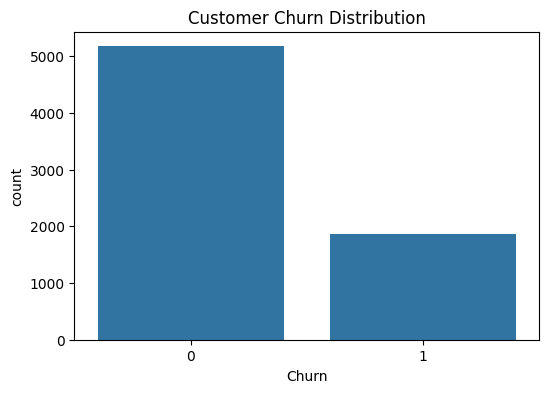

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

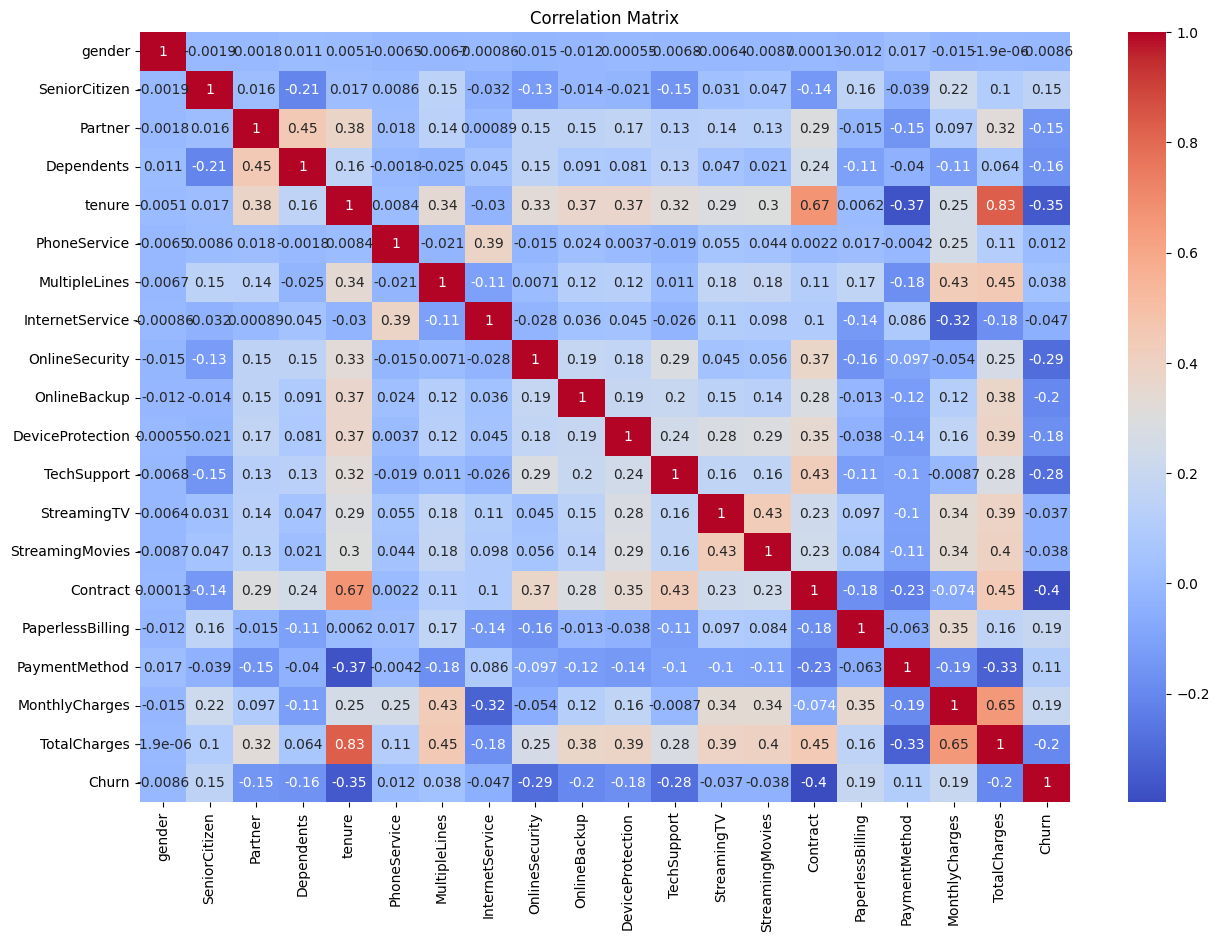

In [12]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier()

In [16]:
parameters = {

    "n_estimators": [100, 200],

    "max_depth": [5, 10, None]
}

In [17]:
grid_search = GridSearchCV(

    estimator=model,

    param_grid=parameters,

    cv=3,

    scoring="accuracy"
)

In [18]:
grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [19]:
best_model = grid_search.best_estimator_

best_model

RandomForestClassifier(max_depth=10, n_estimators=200)

In [20]:
predictions = best_model.predict(X_test)

In [21]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.8062455642299503


In [22]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [23]:
cm = confusion_matrix(
    y_test,
    predictions
)

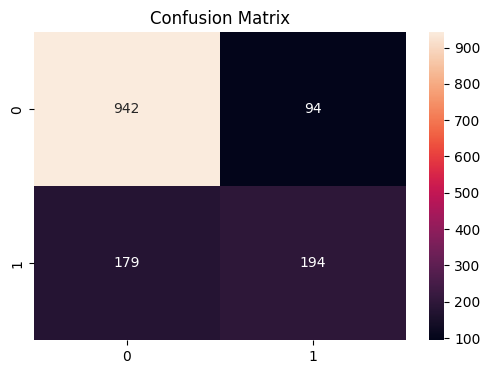

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [25]:
joblib.dump(
    best_model,
    "churn_model.pkl"
)

['churn_model.pkl']

In [26]:
import gradio as gr

In [30]:
import gradio as gr
import pandas as pd


def predict_churn(

    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    paperless_billing,
    monthly_charges,
    total_charges

):

    input_data = pd.DataFrame([{

        "gender": gender,

        "SeniorCitizen": senior_citizen,

        "Partner": partner,

        "Dependents": dependents,

        "tenure": tenure,

        "PhoneService": phone_service,

        "PaperlessBilling": paperless_billing,

        "MonthlyCharges": monthly_charges,

        "TotalCharges": total_charges
    }])

    # Add missing columns with zeros
    for col in X_train.columns:

        if col not in input_data.columns:

            input_data[col] = 0

    # Reorder columns
    input_data = input_data[X_train.columns]

    prediction = best_model.predict(input_data)

    if prediction[0] == 1:

        return "Customer Will Leave"

    return "Customer Will Stay"


interface = gr.Interface(

    fn=predict_churn,

    inputs=[

        gr.Number(label="Gender (0=Female,1=Male)"),

        gr.Number(label="Senior Citizen (0/1)"),

        gr.Number(label="Partner (0/1)"),

        gr.Number(label="Dependents (0/1)"),

        gr.Number(label="Tenure"),

        gr.Number(label="Phone Service (0/1)"),

        gr.Number(label="Paperless Billing (0/1)"),

        gr.Number(label="Monthly Charges"),

        gr.Number(label="Total Charges")
    ],

    outputs="text",

    title="Customer Churn Prediction"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b98a09cc30aa8a4261.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
